In [26]:
import sys
sys.path.append('../src/')

from pdb2mrc import PDB2MRC
from plotting_tools import *
import torch
from scattering import Scattering, complex_potential
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Instantiate class

In [2]:
pdb_code = '6j6j'
pm = PDB2MRC(pdb_code)

## Download PDB file

In [3]:
pm.fetch_pdb(pdb_folder='../pdb-data/')

../pdb-data/6j6j
PDB file saved to: ../pdb-data/6j6j.cif


## Compute particle potential

In [10]:
n = 256
dx = 0.5
pm.build_particle(n=256, dx=0.5)

100%|█████████████████████████████████████████████| 4/4 [00:00<00:00,  4.54it/s]


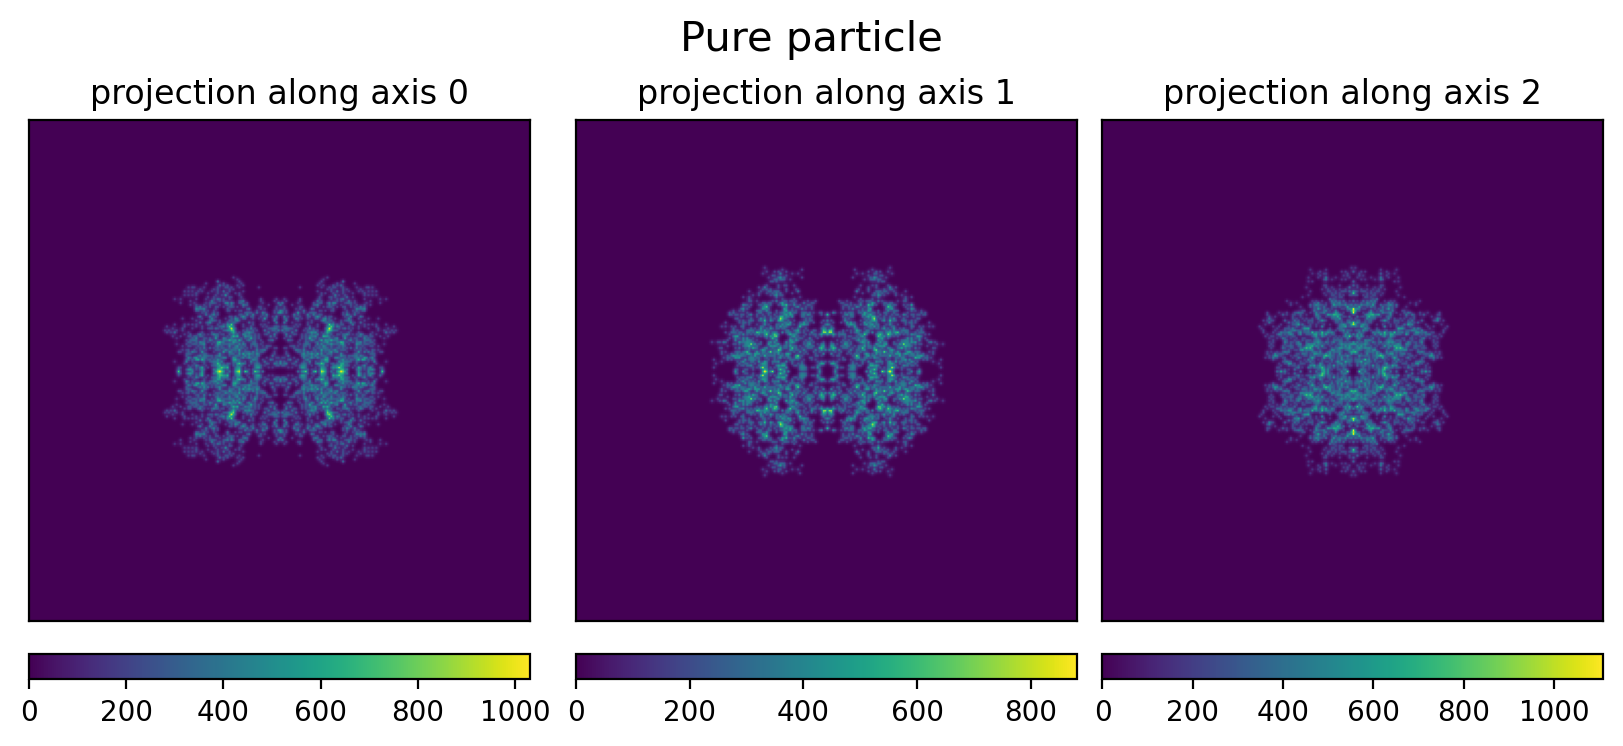

In [5]:
plot3d(pm.particle, title='Pure particle')

## Solvate
Note: Time taken increases exponentially with larger box sizes.
- 256A x 256A x 256A takes 1.5 hours.
- 150A x 150A x 150A takes 3 minutes.
- 100A x 100A x 100A takes 20 seconds.

In [6]:
pm.solvate()

100%|█████████████████████████████████████████████| 5/5 [01:20<00:00, 16.05s/it]


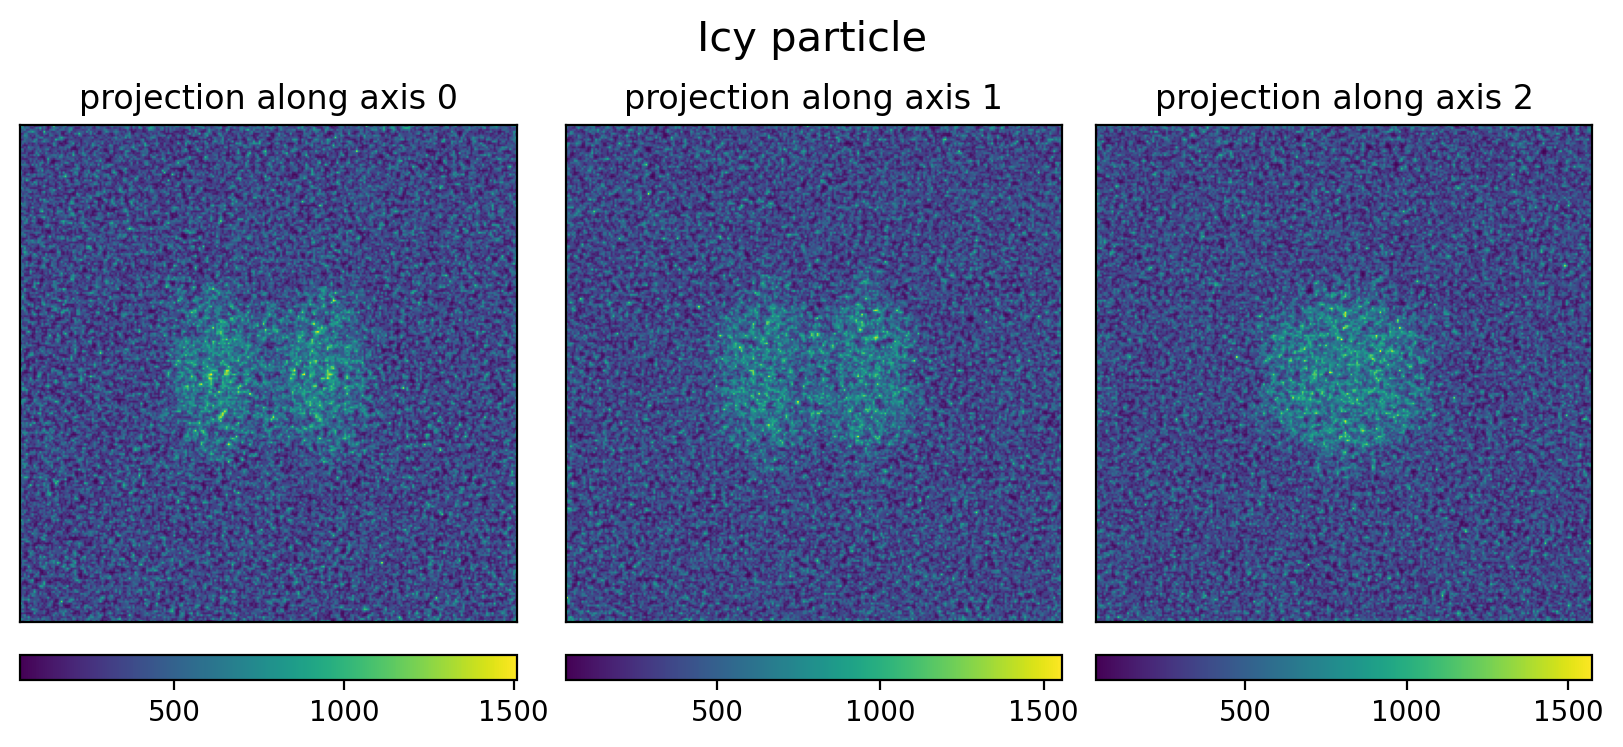

In [7]:
plot3d(pm.icy_particle, title='Icy particle')

## Scattering

In [8]:
method = 'projection'

In [13]:
energy = 200 #kev
dose_per_area = 20 # e-/px
sc = Scattering(pm.icy_particle.shape, dx, energy=energy, dose_per_area=dose_per_area, projectmode=method)

In [15]:
potential = pm.icy_particle.clone()[None,...]
potential.shape

torch.Size([1, 256, 256, 256])

In [27]:
complex_potential = complex_potential(potential)

In [28]:
exitwave = sc(complex_potential)

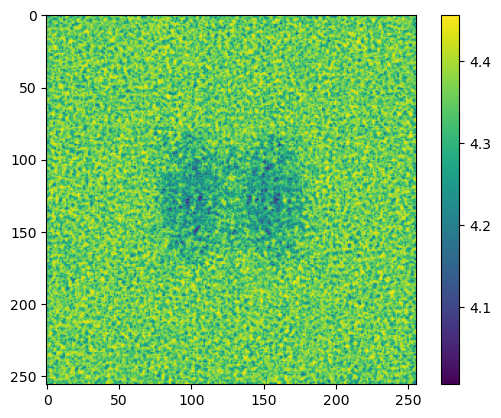

In [30]:
plt.imshow(torch.abs(exitwave[0]))
plt.colorbar()